In [1]:
import os
import pandas as pd

In [2]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()  # чтобы не показывалось пустое окно
path = askopenfilename(title="Выбери файл student_digital_life")
print("Выбран файл:", path)

Выбран файл: D:/Пользователь/Downloads/student_digital_life.csv


In [3]:
ext = os.path.splitext(path)[1].lower()
print("Расширение:", ext)

if ext in [".xlsx", ".xls"]:
    df = pd.read_excel(path)
elif ext == ".csv":
    df = pd.read_csv(path)
else:
    raise ValueError("Неизвестный формат файла: " + ext)

df.head()

Расширение: .csv


,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


In [4]:
[c for c in df.columns if "score" in c.lower() or "exam" in c.lower()]

['final_exam_score']

In [5]:
target = "final_exam_score"  # если так называется, иначе поменяем
df[target].describe()

count    15000.000000
mean        80.344360
std         18.434455
min          2.630000
25%         68.730000
50%         83.745000
75%         97.810000
max        100.000000
Name: final_exam_score, dtype: float64

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# 1) Целевая переменная
target = "final_exam_score"

# 2) Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# 3) Определяем типы столбцов
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# 4) Препроцессинг
numeric = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric, num_cols),
        ("cat", categorical, cat_cols)
    ]
)

# 5) Модель
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# 6) Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7) Обучаем и предсказываем
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

# 8) Метрики (RMSE считаем вручную, чтобы работало на любой версии sklearn)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RESULTS:")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))

RESULTS:
MAE : 8.644
RMSE: 10.935
R2  : 0.657


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Baseline: всегда предсказываем среднее по train
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("BASELINE (predict mean):")
print("MAE :", round(baseline_mae, 3))
print("RMSE:", round(baseline_rmse, 3))
print("R2  :", round(baseline_r2, 3))

print("\nYOUR MODEL (RandomForest):")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))

print("\nIMPROVEMENT vs baseline:")
print("MAE improvement:", round(baseline_mae - mae, 3))
print("RMSE improvement:", round(baseline_rmse - rmse, 3))


# 2) Топ признаков (feature importances)
# Получаем имена фич после OneHotEncoder
pre = pipe.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = []
feature_names += num_cols
if len(cat_cols) > 0:
    feature_names += list(ohe.get_feature_names_out(cat_cols))

importances = pipe.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

print("\nTOP-15 FEATURES:")
display(fi.head(15))

BASELINE (predict mean):
MAE : 15.242
RMSE: 18.684
R2  : -0.0

YOUR MODEL (RandomForest):
MAE : 8.644
RMSE: 10.935
R2  : 0.657

IMPROVEMENT vs baseline:
MAE improvement: 6.598
RMSE improvement: 7.749

TOP-15 FEATURES:


,feature,importance
2,study_hours_per_day,0.487002
10,assignment_completion_percent,0.067776
7,sleep_hours,0.065821
3,smartphone_usage_hours,0.056788
12,motivation_level,0.051771
9,class_attendance_percent,0.047807
17,mental_health_status_Poor,0.045093
5,gaming_hours,0.031412
8,exercise_hours,0.027025
6,streaming_hours,0.023420


In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

target = "final_exam_score"

# убираем ID, если есть
drop_cols = [c for c in ["student_id"] if c in df.columns]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric, num_cols), ("cat", categorical, cat_cols)]
)

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

pipe2 = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe2.fit(X_train, y_train)
pred = pipe2.predict(X_test)

mae2 = mean_absolute_error(y_test, pred)
rmse2 = np.sqrt(mean_squared_error(y_test, pred))
r22 = r2_score(y_test, pred)

print("WITHOUT student_id:")
print("MAE :", round(mae2, 3))
print("RMSE:", round(rmse2, 3))
print("R2  :", round(r22, 3))

# feature importances
pre = pipe2.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = num_cols + (list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) else [])
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": pipe2.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("\nTOP-15 FEATURES (without ID):")
display(fi.head(15))

WITHOUT student_id:
MAE : 8.635
RMSE: 10.92
R2  : 0.658

TOP-15 FEATURES (without ID):


,feature,importance
1,study_hours_per_day,0.488916
9,assignment_completion_percent,0.069644
6,sleep_hours,0.067877
2,smartphone_usage_hours,0.058662
11,motivation_level,0.053786
8,class_attendance_percent,0.049738
16,mental_health_status_Poor,0.045117
4,gaming_hours,0.033273
7,exercise_hours,0.028917
5,streaming_hours,0.025150


In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

target = "final_exam_score"
drop_cols = [c for c in ["student_id"] if c in df.columns]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric, num_cols), ("cat", categorical, cat_cols)]
)

model = HistGradientBoostingRegressor(
    random_state=42,
    max_depth=6,
    learning_rate=0.08,
    max_iter=400
)

pipe_gb = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_gb.fit(X_train, y_train)
pred = pipe_gb.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("HistGradientBoosting:")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))

HistGradientBoosting:
MAE : 8.211
RMSE: 10.482
R2  : 0.685


In [12]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# MAE в cross_val_score нужно делать "отрицательным", так устроен sklearn
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

scores = cross_val_score(pipe_gb, X, y, cv=5, scoring=mae_scorer)
mae_cv = -scores

print("CV MAE (5 folds):")
print("mean:", round(mae_cv.mean(), 3))
print("std :", round(mae_cv.std(), 3))
print("all :", [round(x,3) for x in mae_cv])

CV MAE (5 folds):
mean: 8.115
std : 0.121
all : [np.float64(7.942), np.float64(8.193), np.float64(8.291), np.float64(8.039), np.float64(8.109)]


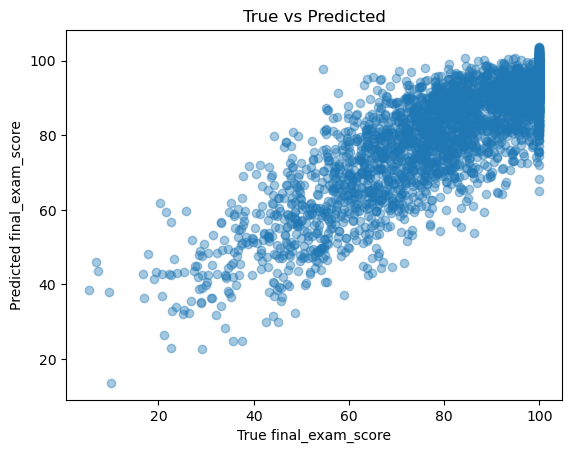

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, pred, alpha=0.4)
plt.xlabel("True final_exam_score")
plt.ylabel("Predicted final_exam_score")
plt.title("True vs Predicted")
plt.show()

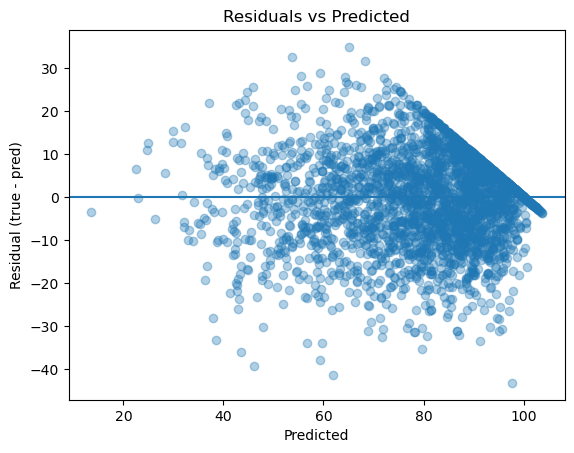

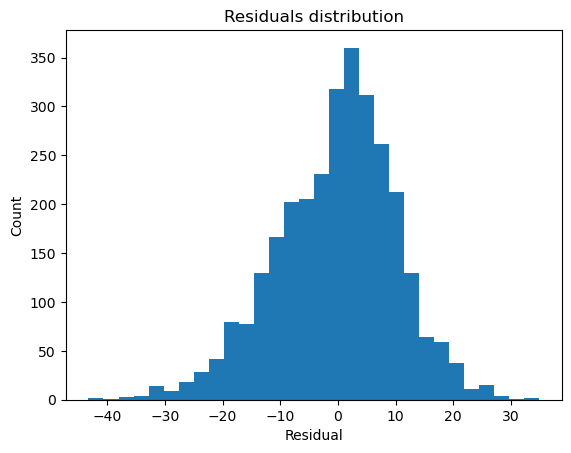

In [14]:
import matplotlib.pyplot as plt

resid = y_test - pred

plt.figure()
plt.scatter(pred, resid, alpha=0.35)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(resid, bins=30)
plt.title("Residuals distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [15]:
import pandas as pd
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipe_gb, X_test, y_test,
    n_repeats=8,
    random_state=42,
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(15)

,feature,importance_mean,importance_std
2,study_hours_per_day,0.927741,0.026777
12,mental_health_status,0.101154,0.004981
7,sleep_hours,0.082799,0.003859
10,assignment_completion_percent,0.070199,0.001805
3,smartphone_usage_hours,0.059213,0.003979
15,motivation_level,0.046272,0.004691
9,class_attendance_percent,0.035626,0.003235
5,gaming_hours,0.018496,0.002250
13,parent_education_level,0.014221,0.001473
8,exercise_hours,0.007452,0.001897
